# Project; **Netflix Strategy Analysis**

**Objective** ;To analyze Netflix's library growth and content distribution using Python.

**Key Tools:** Pandas, Matplotlib, KaggleHub.

**Major Finding: 7**0% of Netflix's library is "Modern" content (released after 2015), showing a massive shift toward original production.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/netflix-shows")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'netflix-shows' dataset.
Path to dataset files: /kaggle/input/netflix-shows


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import os

In [ ]:
# Re-running the download to be safe
path = kagglehub.dataset_download("shivamb/netflix-shows")
files = os.listdir(path)
file_path = os.path.join(path, files[0])

# This creates the 'df' variable. If this isn't run, everything else says NameError!
df = pd.read_csv(file_path)

Using Colab cache for faster access to the 'netflix-shows' dataset.


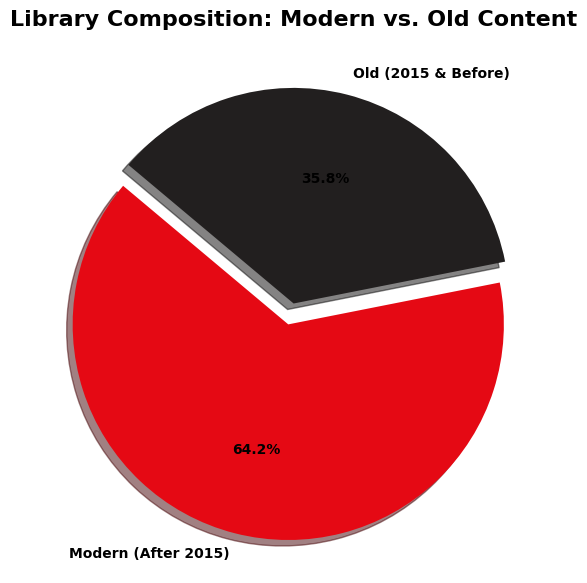

In [ ]:
import matplotlib.pyplot as plt

# 1. Count how many are 'Modern' vs 'Old'
# We define Modern as anything released after 2015
modern_count = df[df['release_year'] > 2015].shape[0]
old_count = df[df['release_year'] <= 2015].shape[0]

# 2. Prepare the data for the chart
labels = ['Modern (After 2015)', 'Old (2015 & Before)']
sizes = [modern_count, old_count]
colors = ['#E50914', '#221f1f'] # Netflix Red and Netflix Black
explode = (0.1, 0)  # This "pops out" the Modern slice for emphasis

# 3. Create the Pie Chart
plt.figure(figsize=(10, 7))
plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=140, colors=colors, textprops={'color':"black", 'weight':'bold'})

plt.title('Library Composition: Modern vs. Old Content', fontsize=16, fontweight='bold')
plt.show()

# Library Composition: Recency Analysis

 I categorized the Netflix library into two segments: Modern (post-2015) and Legacy (2015 and older). This pie chart reveals that the vast majority of Netflix’s catalog is relatively new.

Created a custom boolean logic to filter the release_year column.

We concluded that Netflix prioritizes high-turnover, fresh content over maintaining a deep historical archive. This aligns with their strategy to reduce licensing costs for older titles and invest in 'Originals'




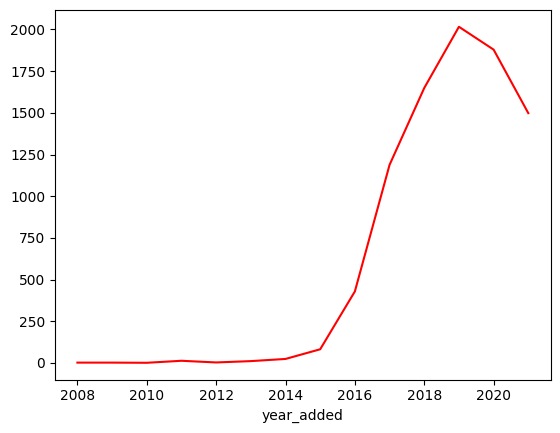

In [ ]:
# Now run your cleaning code again
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year

# Create the chart
df['year_added'].value_counts().sort_index().plot(kind='line', color='red')
plt.show()

# The Streaming Explosion (2008 – 2021)

This time-series analysis tracks when content was actually added to the platform.

We note that the *date_added* column was converted from a string to a datetime object to extract the year.

This implies that there is a massive inflection point around 2016. The exponential growth seen here correlates with Netflix's global expansion and the massive scaling of their 'Netflix Originals' production budget.


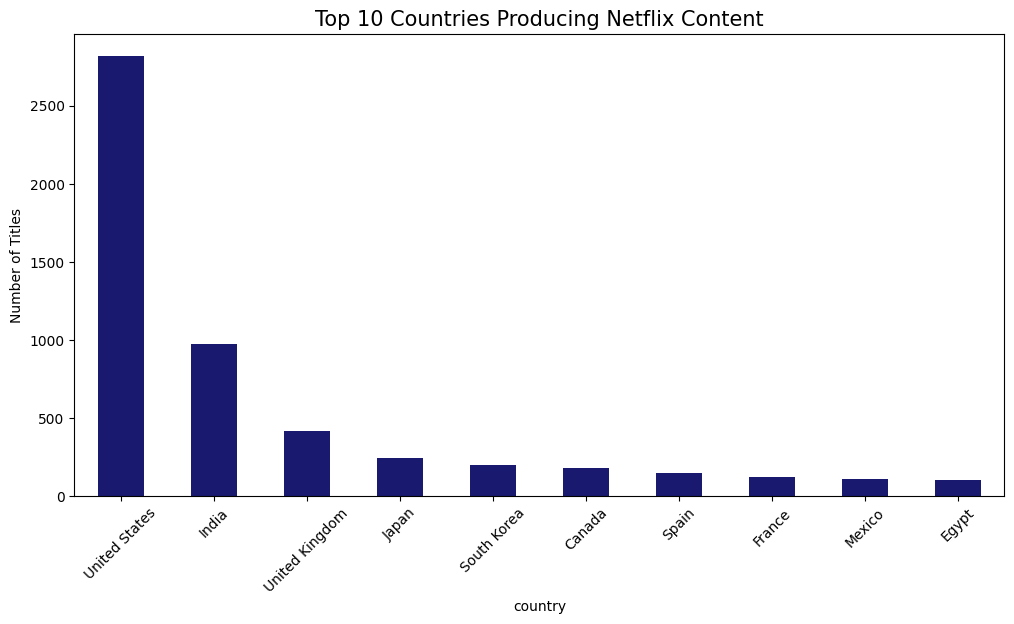

In [ ]:
# Create a Bar Chart of the Top 10 Countries
top_10_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_10_countries.plot(kind='bar', color='midnightblue')
plt.title('Top 10 Countries Producing Netflix Content', fontsize=15)
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

# Global Content Distribution
 While Netflix is an American company, its library is increasingly international. This chart ranks the top 10 countries by total volume of titles.

 Used .value_counts() and .head(10) to aggregate the top producers.

this proves that outside of the United States, India and the UK are the largest contributors. This highlights Netflix's heavy investment in 'Local Language' content to capture emerging international markets.

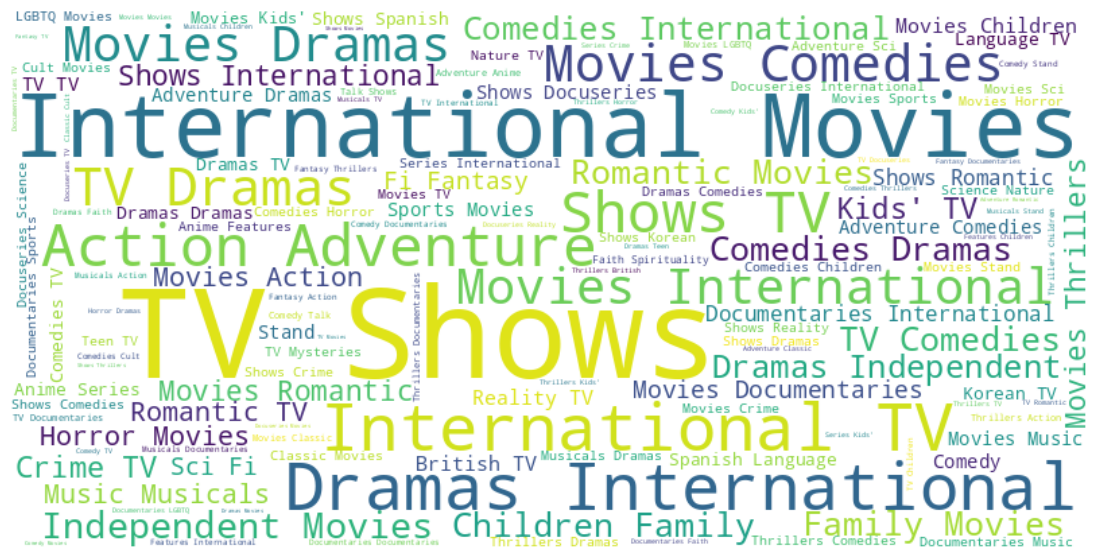

In [ ]:
from wordcloud import WordCloud

# Combine all genres into one big string
text = " ".join(cat for cat in df.listed_in)

# Generate the cloud
wordcloud = WordCloud(background_color="white", width=800, height=400).generate(text)

# Display it
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# Genre Density & Content Themes

This visualization highlights the most frequent genres appearing in the *listed_in *column.

We utilized the WordCloud library to parse and visualize text data frequency.

This implies that the 'International Movies,' 'Dramas,' and 'Comedies' dominate the cloud. This suggests Netflix focuses on 'universal' genres that translate well across different cultures and languages.

 **Final conclusion**

 Based on the data, Netflix has transitioned from a diverse archive to a "Current-First" platform. Their growth spiked in 2016, and they heavily prioritize the Indian and UK markets for international expansion.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# 1. Remove "stop words" (like 'the', 'is', 'a') and turn descriptions into a matrix
tfidf = TfidfVectorizer(stop_words='english')
df['description'] = df['description'].fillna('') # Handle empty descriptions
tfidf_matrix = tfidf.fit_transform(df['description'])

# 2. Calculate "Cosine Similarity" (How close is one movie to another?)
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# 3. Create a function to get recommendations
def get_recommendations(title, cosine_sim=cosine_sim):
    # Find the index of the movie that matches the title
    idx = df[df['title'] == title].index[0]

    # Get the pairwise similarity scores of all movies with that movie
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort the movies based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the 5 most similar movies
    sim_scores = sim_scores[1:6]

    # Get the movie indices
    movie_indices = [i[0] for i in sim_scores]

    # Return the top 5 most similar movies
    return df['title'].iloc[movie_indices]



In [ ]:
print("If you liked 'Zodiac', you might also like:")
print(get_recommendations('Zodiac'))

If you liked 'Zodiac', you might also like:
5952         Victim of Beauty
200           Krishna Cottage
4453    No One Killed Jessica
6379        Brooklyn's Finest
6212              Bad Boys II
Name: title, dtype: object
